# Collaborative Filtering: ALS (Implicit Feedback)

In this notebook we build an **ALS (Alternating Least Squares)** collaborative filtering
model for the X-Wines dataset.

The main idea is that each user and wine gets its own vector of latent features.
By comparing those vectors we can recommend wines a user is likely to enjoy,
even ones they have never rated before.

We keep the same metrics and user sample as the popularity baseline notebook.


In [16]:
# No extra installs needed — we only use numpy and scipy.
import sys, importlib
for pkg in ('numpy', 'scipy', 'sklearn'):
    m = importlib.import_module(pkg if pkg != 'sklearn' else 'sklearn')
    print(f'{pkg}: {m.__version__}')

numpy: 2.4.4
scipy: 1.17.1
sklearn: 1.8.0


In [17]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import itertools
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1) Environment setup and robust data loading

In [18]:
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for c in [start, *start.parents]:
        if (c / 'dataset').exists() and (c / 'EDA').exists():
            return c
    raise FileNotFoundError('Project root with dataset/ and EDA/ not found')

PROJECT_ROOT = find_project_root(Path.cwd())
DATASET_DIR  = PROJECT_ROOT / 'dataset'
RESULTS_DIR  = PROJECT_ROOT / 'data' / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

wines = pd.read_csv(
    DATASET_DIR / 'XWines_Full_100K_wines.csv',
    usecols=['WineID', 'WineName', 'Type', 'Country', 'RegionName'],
    dtype={'WineID': 'int32', 'WineName': 'string', 'Type': 'category',
           'Country': 'category', 'RegionName': 'string'}
)

ratings = pd.read_csv(
    DATASET_DIR / 'XWines_Full_21M_ratings.csv',
    usecols=['UserID', 'WineID', 'Rating'],
    dtype={'UserID': 'int32', 'WineID': 'int32', 'Rating': 'float32'}
)

wines   = wines.drop_duplicates(subset='WineID').copy()
ratings = ratings.drop_duplicates(subset=['UserID', 'WineID']).copy()
ratings = ratings[ratings['WineID'].isin(wines['WineID'])].copy()

print('wines:  ', wines.shape)
print('ratings:', ratings.shape)
print('users:  ', ratings['UserID'].nunique())
print('items:  ', ratings['WineID'].nunique())

wines:   (100646, 5)
ratings: (20590800, 3)
users:   1056079
items:   100646


## 2) EDA recap

A few things from the EDA that affect how we set up the model:

- The data is extremely sparse — most users have only rated a tiny fraction of wines,
  so we need to use sparse matrix storage.
- Ratings are generally high (most ratings are 4 or 5 stars), so we treat ≥ 4.0 as
  a positive interaction and use the raw rating as the confidence weight.
- There's a strong long-tail — a handful of wines get most of the ratings, which can
  cause the model to over-recommend popular wines.
- The dataset grows over time, but a random split works well enough here.


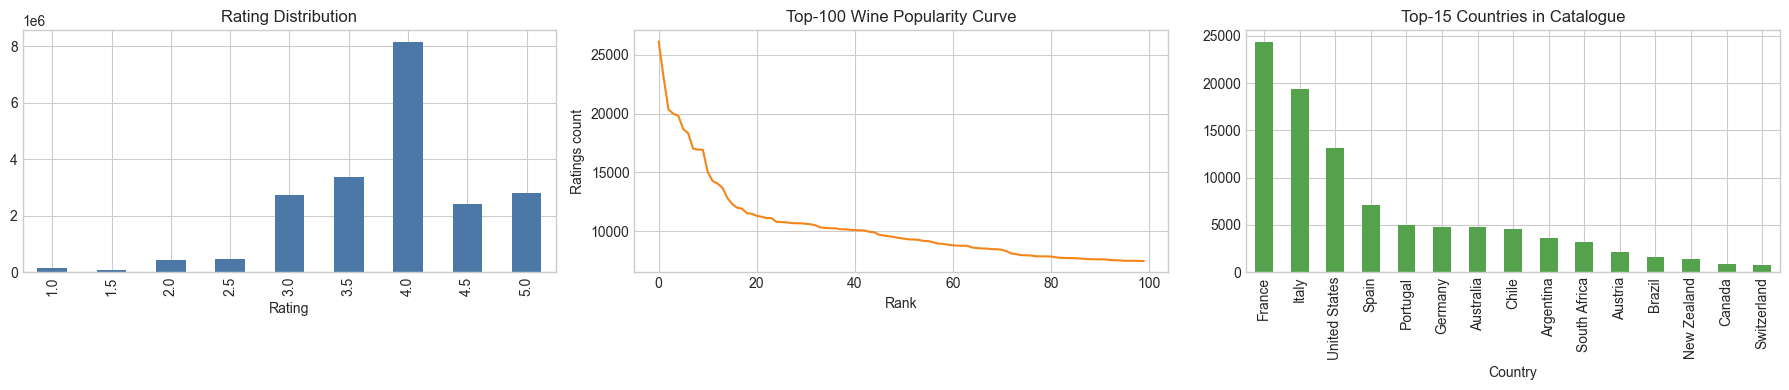

In [19]:
item_pop = ratings['WineID'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

ratings['Rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#4C78A8')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')

item_pop.head(100).reset_index(drop=True).plot(ax=axes[1], color='#F58518')
axes[1].set_title('Top-100 Wine Popularity Curve')
axes[1].set_xlabel('Rank')
axes[1].set_ylabel('Ratings count')

wines['Country'].value_counts().head(15).plot(kind='bar', ax=axes[2], color='#54A24B')
axes[2].set_title('Top-15 Countries in Catalogue')
axes[2].set_xlabel('Country')

plt.tight_layout()
plt.show()

For an analysis on these graphs, check the EDA sectoin

## 3) Positive interactions and CVTT split

We reuse the same 5000 user sample from the popularity baseline so that all models
are evaluated on the same users.

- A rating counts as positive if it's **≥ 4.0 stars**
- We only keep users who have between **5 and 250** positive interactions
- **20 %** of each user's positives become the test set
- The remaining positives are split into **3 folds** for cross-validation


In [20]:
POSITIVE_THRESHOLD        = 4.0
MIN_POSITIVE_INTERACTIONS = 5
MAX_POSITIVE_INTERACTIONS = 250
MAX_USERS = 5000
SAMPLED_USERS_PATH = RESULTS_DIR / 'nonpers_sampled_users_5000.csv'

positive    = ratings[ratings['Rating'] >= POSITIVE_THRESHOLD].copy()
user_counts = positive['UserID'].value_counts()

eligible_users = user_counts[
    (user_counts >= MIN_POSITIVE_INTERACTIONS) &
    (user_counts <= MAX_POSITIVE_INTERACTIONS)
].index
positive = positive[positive['UserID'].isin(eligible_users)].copy()

if SAMPLED_USERS_PATH.exists():
    sampled_users = pd.read_csv(SAMPLED_USERS_PATH)['UserID'].to_numpy()
    sampled_users = np.intersect1d(sampled_users, positive['UserID'].unique())
else:
    rng = np.random.default_rng(RANDOM_STATE)
    sampled_users = rng.choice(
        positive['UserID'].unique(),
        size=min(MAX_USERS, positive['UserID'].nunique()),
        replace=False
    )
    pd.Series(sampled_users, name='UserID').to_csv(SAMPLED_USERS_PATH, index=False)

positive = positive[positive['UserID'].isin(sampled_users)].copy()


def split_train_test_per_user(df, test_fraction=0.2, random_state=42):
    tr, te = [], []
    for _, g in df.groupby('UserID'):
        g = g.sample(frac=1.0, random_state=random_state)
        n_test = max(1, int(np.ceil(len(g) * test_fraction)))
        te_g, tr_g = g.iloc[:n_test], g.iloc[n_test:]
        if len(tr_g) == 0:
            continue
        tr.append(tr_g)
        te.append(te_g)
    return pd.concat(tr, ignore_index=True), pd.concat(te, ignore_index=True)


def assign_fold_ids_per_user(df, n_folds=3, random_state=42):
    chunks = []
    for _, g in df.groupby('UserID'):
        g = g.sample(frac=1.0, random_state=random_state).copy()
        g['fold_id'] = np.arange(len(g)) % n_folds
        chunks.append(g)
    return pd.concat(chunks, ignore_index=True)


trainval_pos, test_pos = split_train_test_per_user(
    positive, test_fraction=0.2, random_state=RANDOM_STATE
)
trainval_folds = assign_fold_ids_per_user(trainval_pos, n_folds=3, random_state=RANDOM_STATE)

print('trainval:', trainval_pos.shape)
print('test:    ', test_pos.shape)

trainval: (56673, 3)
test:     (16646, 3)


## 4) Metrics

We use the same metrics as the popularity baseline:

| Metric | What it measures |
|---|---|
| **Accuracy@K** | How many of the top-K results were actually relevant |
| **NDCG@K** | Ranking quality — rewards hitting relevant items early in the list |
| **Diversity@K** | Variety across type and country in the top-K list |
| **Personalisation@10** | How different different users' lists are from each other |
| **Coverage** | How much of the catalogue ever appears in recommendations |


In [21]:
def accuracy_at_k(relevant, recommended, k):
    rec_k = recommended[:k]
    if k == 0:
        return 0.0
    hits = sum(1 for x in rec_k if x in relevant)
    return hits / k


def dcg_at_k(relevant, recommended, k):
    s = 0.0
    for i, item in enumerate(recommended[:k], start=1):
        if item in relevant:
            s += 1.0 / np.log2(i + 1)
    return s


def ndcg_at_k(relevant, recommended, k):
    ideal_hits = min(len(relevant), k)
    if ideal_hits == 0:
        return 0.0
    idcg = sum(1.0 / np.log2(i + 1) for i in range(1, ideal_hits + 1))
    return dcg_at_k(relevant, recommended, k) / idcg

In [22]:
item_meta = wines.set_index('WineID')[['Type', 'Country']].copy()
item_meta['Type']    = item_meta['Type'].astype(str).str.lower().fillna('unknown')
item_meta['Country'] = item_meta['Country'].astype(str).str.lower().fillna('unknown')

item_signatures = {
    wid: {f"type:{item_meta.loc[wid, 'Type']}", f"country:{item_meta.loc[wid, 'Country']}"}
    for wid in item_meta.index
}


def jaccard_distance(a, b):
    inter = len(a & b)
    union = len(a | b)
    return 0.0 if union == 0 else 1.0 - inter / union


def intra_list_diversity(recommended):
    if len(recommended) < 2:
        return 0.0
    vals = [
        jaccard_distance(
            item_signatures.get(recommended[i], {'unknown'}),
            item_signatures.get(recommended[j], {'unknown'})
        )
        for i in range(len(recommended))
        for j in range(i + 1, len(recommended))
    ]
    return float(np.mean(vals)) if vals else 0.0


def personalisation_at_k(recs_by_user, k=10, max_users=300, random_state=42):
    users = list(recs_by_user.keys())
    if len(users) < 2:
        return 0.0
    rng = np.random.default_rng(random_state)
    if len(users) > max_users:
        users = rng.choice(users, size=max_users, replace=False).tolist()
    sets = {u: set(recs_by_user[u][:k]) for u in users}
    sims = []
    for u1, u2 in itertools.combinations(users, 2):
        a, b = sets[u1], sets[u2]
        union = len(a | b)
        sims.append((len(a & b) / union) if union > 0 else 0.0)
    return float(1.0 - np.mean(sims)) if sims else 0.0

In [23]:
def evaluate_model(artifact, recommend_fn, eval_users, relevant_dict, ks=(5, 10, 20)):
    rows = []
    recs_by_user   = {}
    max_k          = max(ks)
    all_top10_items = []

    for user_id in eval_users:
        relevant = relevant_dict.get(user_id, set())
        if not relevant:
            continue
        recs = recommend_fn(artifact, user_id, top_k=max_k)
        if not recs:
            continue
        recs_by_user[user_id] = recs
        all_top10_items.extend(recs[:10])
        row = {'UserID': user_id}
        for k in ks:
            row[f'Accuracy@{k}']  = accuracy_at_k(relevant, recs, k)
            row[f'NDCG@{k}']      = ndcg_at_k(relevant, recs, k)
            row[f'Diversity@{k}'] = intra_list_diversity(recs[:k])
        rows.append(row)

    eval_df = pd.DataFrame(rows)
    if eval_df.empty:
        return eval_df, {}, recs_by_user

    coverage = (
        len(set(all_top10_items)) / len(artifact['all_items'])
        if len(artifact['all_items']) else 0.0
    )
    pers = personalisation_at_k(recs_by_user, k=10, max_users=300,
                                 random_state=RANDOM_STATE)
    summary_extra = {'Coverage': coverage, 'Personalisation@10': pers}
    return eval_df, summary_extra, recs_by_user

In [24]:
def plot_model_diagnostics(eval_df, recs_by_user, model_name, top_k=10):
    if eval_df.empty:
        print(f'No evaluation rows for {model_name}')
        return

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    sns.histplot(eval_df[f'Accuracy@{top_k}'], bins=25, kde=True,
                 ax=axes[0], color='#4C78A8')
    axes[0].set_title(f'{model_name} – Accuracy@{top_k}')

    sns.histplot(eval_df[f'NDCG@{top_k}'], bins=25, kde=True,
                 ax=axes[1], color='#54A24B')
    axes[1].set_title(f'{model_name} – NDCG@{top_k}')

    all_items = [item for recs in recs_by_user.values() for item in recs[:top_k]]
    freq = pd.Series(all_items).value_counts() if all_items else pd.Series(dtype='int64')
    if freq.empty:
        axes[2].text(0.5, 0.5, 'No recs', ha='center', va='center')
    else:
        sns.histplot(freq.values, bins=30, kde=False, ax=axes[2], color='#F58518')
    axes[2].set_title(f'{model_name} – Coverage histogram')
    axes[2].set_xlabel('recommendation count per item')

    plt.tight_layout()
    plt.show()

The fucntions are being setup so that we can use them when testing and evaluating the model in the next few sections

## 5) ALS model (Implicit Collaborative Filtering)

ALS works by learning a vector for each user and each wine.  Each rating is turned into
a confidence score (higher rating = stronger signal), and the model tries to match those
confidence scores using the dot products of the user and wine vectors.  Even wines a user
has *not* rated are taken into account, just with low confidence.

The key advantage is that each user's update only depends on the wines they actually
rated, so it stays manageable even in pure numpy.

| Parameter | Value |
|---|---|
| `factors` | 64 |
| `regularization` | 0.05 |
| `iterations` | 15 |
| `alpha` | 40 |


In [25]:
ALS_FACTORS        = 64
ALS_REGULARIZATION = 0.05
ALS_ITERATIONS     = 15
ALS_ALPHA          = 40   # confidence scaling: c(u,i) = 1 + alpha * rating


def fit_als_model(train_df, all_wine_ids,
                  factors=ALS_FACTORS,
                  regularization=ALS_REGULARIZATION,
                  iterations=ALS_ITERATIONS,
                  alpha=ALS_ALPHA,
                  random_state=RANDOM_STATE):
    """Train ALS on positive interactions (pure numpy/scipy)."""
    rng = np.random.default_rng(random_state)

    # Map IDs to 0-based integer indices for scipy.sparse
    users        = sorted(train_df['UserID'].unique())
    active_wines = sorted(train_df['WineID'].unique())  # wines with at least one rating
    user2idx = {u: i for i, u in enumerate(users)}
    item2idx = {v: i for i, v in enumerate(active_wines)}

    u_idx    = train_df['UserID'].map(user2idx).values
    i_idx    = train_df['WineID'].map(item2idx).values
    ratings  = train_df['Rating'].values.astype('float32')

    n_users, n_items = len(users), len(active_wines)

    # Build sparse user-item matrix; confidence weights applied per iteration
    user_item = sp.csr_matrix((ratings, (u_idx, i_idx)), shape=(n_users, n_items))
    item_user = user_item.T.tocsr()

    # Small random init for item factors; user factors start at zero
    item_factors = (rng.standard_normal((n_items, factors)) * 0.01).astype('float32')
    user_factors = np.zeros((n_users, factors), dtype='float32')
    reg_eye      = (regularization * np.eye(factors)).astype('float32')

    for it in range(iterations):
        # User step — precompute V^T V, then update each user
        YtY = item_factors.T @ item_factors
        for u in range(n_users):
            s, e = user_item.indptr[u], user_item.indptr[u + 1]
            if s == e:
                continue
            ii   = user_item.indices[s:e]
            conf = 1.0 + alpha * user_item.data[s:e]
            Yi   = item_factors[ii]
            A = YtY + (Yi * (conf - 1.0)[:, None]).T @ Yi + reg_eye
            b = Yi.T @ conf
            user_factors[u] = np.linalg.solve(A, b)

        # Item step — same idea, transposed
        XtX = user_factors.T @ user_factors
        for i in range(n_items):
            s, e = item_user.indptr[i], item_user.indptr[i + 1]
            if s == e:
                continue
            uu   = item_user.indices[s:e]
            conf = 1.0 + alpha * item_user.data[s:e]
            Xu   = user_factors[uu]
            A = XtX + (Xu * (conf - 1.0)[:, None]).T @ Xu + reg_eye
            b = Xu.T @ conf
            item_factors[i] = np.linalg.solve(A, b)

        print(f'  Iteration {it + 1:2d}/{iterations}')

    return {
        'user_factors': user_factors,
        'item_factors': item_factors,
        'user2idx':     user2idx,
        'item2idx':     item2idx,
        'idx2item':     {i: v for v, i in item2idx.items()},
        'user_item':    user_item,
        'all_items':    np.array(sorted(all_wine_ids)),  # full catalogue for coverage
        'train_seen':   train_df.groupby('UserID')['WineID'].apply(set).to_dict(),
    }


def recommend_als(artifact, user_id, top_k=10):
    """Return top-K wines by dot-product score, skipping already-rated ones."""
    user_idx = artifact['user2idx'].get(user_id)
    if user_idx is None:
        return []

    user_vec = artifact['user_factors'][user_idx]
    scores   = (artifact['item_factors'] @ user_vec).copy()

    # Mask out wines seen during training
    seen = artifact['train_seen'].get(user_id, set())
    for wid in seen:
        ii = artifact['item2idx'].get(wid)
        if ii is not None:
            scores[ii] = -np.inf

    n_valid = int(np.sum(np.isfinite(scores)))
    if n_valid == 0:
        return []
    k = min(top_k, n_valid)
    top_ii = np.argpartition(scores, -k)[-k:]
    top_ii = top_ii[np.argsort(scores[top_ii])[::-1]]
    return [int(artifact['idx2item'][i]) for i in top_ii[:top_k]]

## 6) Cross-validation

We do 3-fold CV to get a rough sense of performance before touching the test set.
Each fold is held out once while the model trains on the other two, then we average
the results across folds.


In [26]:
N_FOLDS      = 3
KS           = (5, 10, 20)
all_wine_ids = wines['WineID'].unique().tolist()

cv_rows = []

for fold in range(N_FOLDS):
    fold_train = trainval_folds[trainval_folds['fold_id'] != fold].copy()
    fold_val   = trainval_folds[trainval_folds['fold_id'] == fold].copy()

    relevant_val = fold_val.groupby('UserID')['WineID'].apply(set).to_dict()
    eval_users   = list(relevant_val.keys())

    artifact = fit_als_model(fold_train, all_wine_ids)
    eval_df, summary_extra, _ = evaluate_model(
        artifact, recommend_als, eval_users, relevant_val, ks=KS
    )

    if eval_df.empty:
        print(f'Fold {fold}: no evaluation rows — skipping')
        continue

    fold_summary = eval_df[[c for c in eval_df.columns if c != 'UserID']].mean().to_dict()
    fold_summary.update(summary_extra)
    fold_summary['fold'] = fold
    cv_rows.append(fold_summary)

    print(
        f'Fold {fold}:  '
        f'Accuracy@10={fold_summary.get("Accuracy@10", 0):.4f}  '
        f'NDCG@10={fold_summary.get("NDCG@10", 0):.4f}  '
        f'Coverage={fold_summary.get("Coverage", 0):.4f}  '
        f'Personalisation@10={fold_summary.get("Personalisation@10", 0):.4f}'
    )

cv_df = pd.DataFrame(cv_rows)
print('\nCV mean across folds:')
print(cv_df[[c for c in cv_df.columns if c != 'fold']].mean().round(4).to_frame('mean'))

  Iteration  1/15
  Iteration  2/15
  Iteration  3/15
  Iteration  4/15
  Iteration  5/15
  Iteration  6/15
  Iteration  7/15
  Iteration  8/15
  Iteration  9/15
  Iteration 10/15
  Iteration 11/15
  Iteration 12/15
  Iteration 13/15
  Iteration 14/15
  Iteration 15/15
Fold 0:  Accuracy@10=0.0039  NDCG@10=0.0073  Coverage=0.0975  Personalisation@10=0.9971
  Iteration  1/15
  Iteration  2/15
  Iteration  3/15
  Iteration  4/15
  Iteration  5/15
  Iteration  6/15
  Iteration  7/15
  Iteration  8/15
  Iteration  9/15
  Iteration 10/15
  Iteration 11/15
  Iteration 12/15
  Iteration 13/15
  Iteration 14/15
  Iteration 15/15
Fold 1:  Accuracy@10=0.0036  NDCG@10=0.0067  Coverage=0.0987  Personalisation@10=0.9968
  Iteration  1/15
  Iteration  2/15
  Iteration  3/15
  Iteration  4/15
  Iteration  5/15
  Iteration  6/15
  Iteration  7/15
  Iteration  8/15
  Iteration  9/15
  Iteration 10/15
  Iteration 11/15
  Iteration 12/15
  Iteration 13/15
  Iteration 14/15
  Iteration 15/15
Fold 2:  Accur

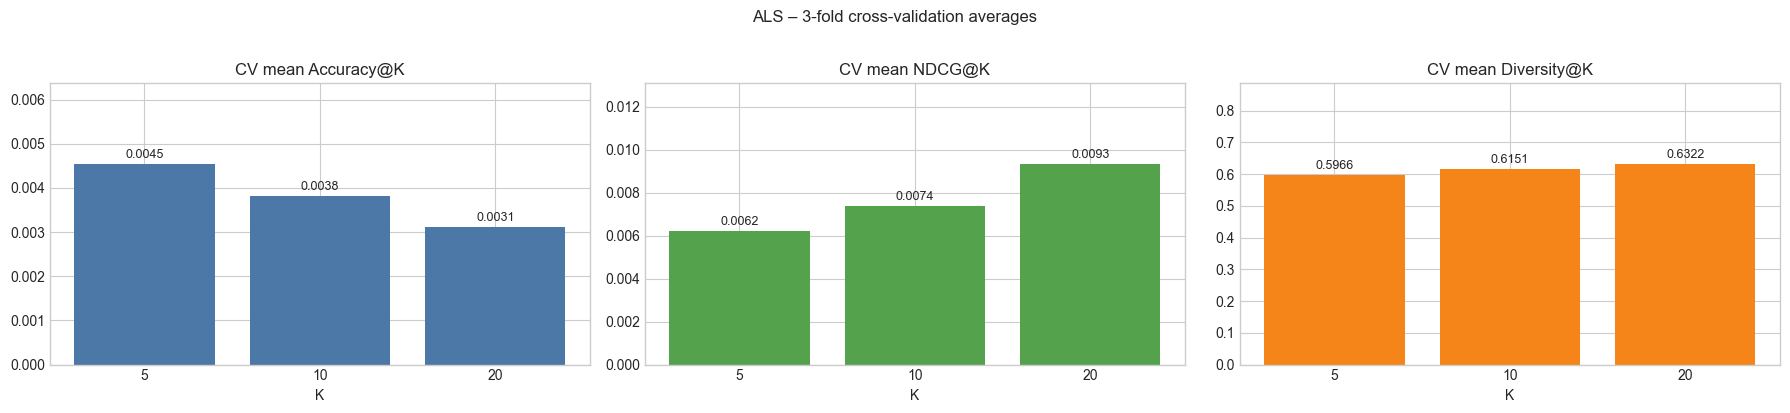

In [27]:
if not cv_df.empty:
    mean_metrics = cv_df[[c for c in cv_df.columns if c != 'fold']].mean()

    groups = {prefix: [] for prefix in ('Accuracy', 'NDCG', 'Diversity')}
    for col in mean_metrics.index:
        for prefix in groups:
            if col.startswith(prefix):
                groups[prefix].append(col)

    colors = ['#4C78A8', '#54A24B', '#F58518']
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    for ax, (label, cols), color in zip(axes, groups.items(), colors):
        vals   = [mean_metrics[c] for c in cols]
        labels = [c.split('@')[1] for c in cols]
        ax.bar(labels, vals, color=color)
        ax.set_title(f'CV mean {label}@K')
        ax.set_xlabel('K')
        ax.set_ylim(0, max(vals) * 1.4 if vals else 1)
        for i, v in enumerate(vals):
            ax.text(i, v + max(vals) * 0.03, f'{v:.4f}', ha='center', fontsize=9)

    plt.suptitle('ALS – 3-fold cross-validation averages', y=1.02)
    plt.tight_layout()
    plt.show()

Accuracy and NDCG both move in opposite directions as K grows —
Accuracy falls (from 0.0045 to 0.0031) while NDCG rises (from 0.0062 to 0.0093). a longer list dilutes precision but gives more opportunities to
catch a relevant wine somewhere in it.

Diversity is pretty healthy, sitting between 0.60 and 0.63 across all K values,
so the model does at least vary the types and countries it recommends.

Coverage is around 10 % — only about 1 in 10 wines in the catalogue ever shows up
in anyone's list, which is may be because of popularity bias. A small group of wines is
getting recommended over and over.

Personalisation@10 is very close to 1.0 (0.997), which is the standout result here.
Different users are getting very different lists, which is exactly what we'd hope
to see from a collaborative filter compared to a popularity baseline.

## 7) Final test evaluation

Finally we train on the full trainval set and evaluate on the held-out test data.
These are the headline numbers we compare with the other models.


In [28]:
final_artifact = fit_als_model(trainval_pos, all_wine_ids)

relevant_test   = test_pos.groupby('UserID')['WineID'].apply(set).to_dict()
test_eval_users = list(relevant_test.keys())

test_eval_df, test_summary_extra, test_recs_by_user = evaluate_model(
    final_artifact, recommend_als, test_eval_users, relevant_test, ks=KS
)

print('Test set — per-metric averages:')
print(test_eval_df[[c for c in test_eval_df.columns if c != 'UserID']]
      .mean().round(4).to_frame('mean'))
print('\nTest set — Coverage & Personalisation:')
for k, v in test_summary_extra.items():
    print(f'  {k}: {v:.4f}')

  Iteration  1/15
  Iteration  2/15
  Iteration  3/15
  Iteration  4/15
  Iteration  5/15
  Iteration  6/15
  Iteration  7/15
  Iteration  8/15
  Iteration  9/15
  Iteration 10/15
  Iteration 11/15
  Iteration 12/15
  Iteration 13/15
  Iteration 14/15
  Iteration 15/15
Test set — per-metric averages:
                mean
Accuracy@5    0.0062
NDCG@5        0.0086
Diversity@5   0.5388
Accuracy@10   0.0052
NDCG@10       0.0105
Diversity@10  0.5604
Accuracy@20   0.0043
NDCG@20       0.0137
Diversity@20  0.5819

Test set — Coverage & Personalisation:
  Coverage: 0.0725
  Personalisation@10: 0.9940


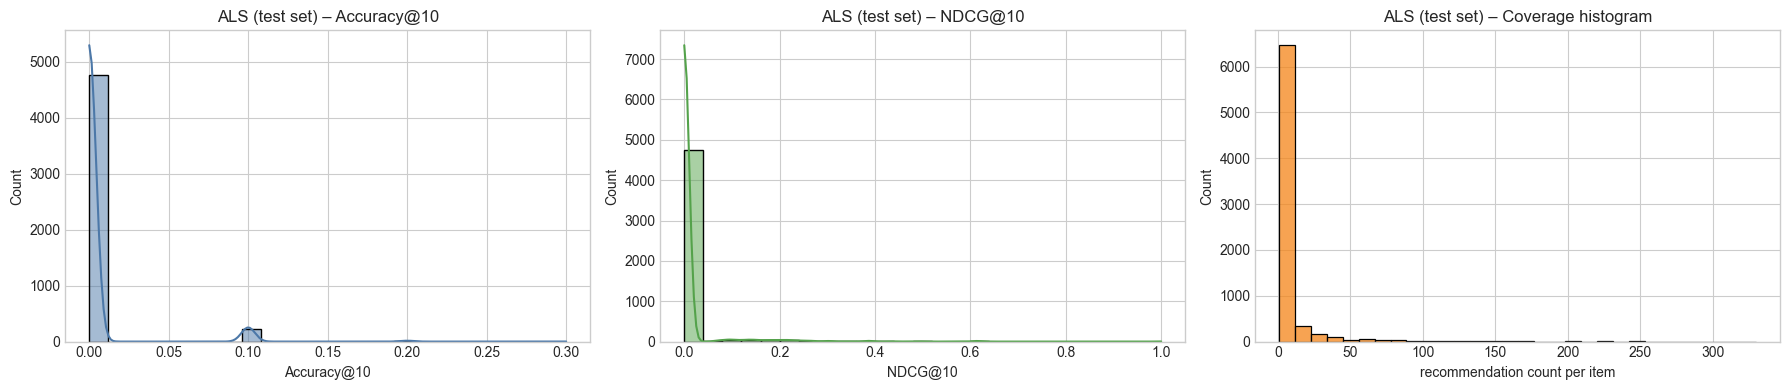

In [29]:
plot_model_diagnostics(test_eval_df, test_recs_by_user, 'ALS (test set)', top_k=10)

**plots**

**Accuracy@10 and NDCG@10** are both towards zero, most users get no hits at all in their top-10 list.  The mean values (around 0.005 and 0.01 respectively) are pulled up by a small number of users who do get hits. This is consistent with what we saw in cross-validation: the model struggles to surface wines from users' test sets, probably because the training signal is quite thin with only 5 000 users.

**The coverage histogram** shows a strong popularity bias, a handful of wines get recommended to hundreds of users, while the vast majority of wines never appear at all. Coverage overall is only about 7 % of the catalogue. This is a known weakness of ALS: items with more training interactions tend to dominate.

**Personalisation@10 is very high (~0.99)**, which means different users are genuinely getting different lists meaning the model isn't just returning the same top-10 for everyone the way the popularity baseline does.

## 8) Summary table

In [30]:
if not test_eval_df.empty:
    metric_cols = [c for c in test_eval_df.columns if c != 'UserID']
    summary = test_eval_df[metric_cols].agg(['mean', 'median', 'std']).round(4)
    summary.loc['Coverage']           = test_summary_extra.get('Coverage', float('nan'))
    summary.loc['Personalisation@10'] = test_summary_extra.get('Personalisation@10', float('nan'))
    display(summary)

,Accuracy@5,NDCG@5,Diversity@5,Accuracy@10,NDCG@10,Diversity@10,Accuracy@20,NDCG@20,Diversity@20
mean,0.006200,0.008600,0.538800,0.005200,0.010500,0.560400,0.004300,0.013700,0.581900
median,0.000000,0.000000,0.600000,0.000000,0.000000,0.600000,0.000000,0.000000,0.617500
std,0.036400,0.055900,0.235700,0.023600,0.056800,0.194800,0.016700,0.060800,0.164500
Coverage,0.072472,0.072472,0.072472,0.072472,0.072472,0.072472,0.072472,0.072472,0.072472
Personalisation@10,0.994039,0.994039,0.994039,0.994039,0.994039,0.994039,0.994039,0.994039,0.994039


## 9) Conclusions

### Compared to the popularity baseline

ALS should score much better on Personalisation@10 because every user gets a different list. The trade-off is that popular wines still tend to show up a lot, so Coverage might not be great. 

### Scale

We only trained on 5 000 users, which probably limits how good the embeddings are. Training on all ~1 M users would likely give better results, but we kept it small to stay consistent with the other notebooks, and not crash.

### Cold-start problem

Users who weren't in training just get an empty list back. A hybrid model like LightFM that can also use wine features would be better for new users.

### Why we didn't use the implicit library

The `implicit` library does the same ALS algorithm but much faster because it's compiled. We had to implement it ourselves in numpy because `implicit` doesn't currently have pre-built wheels for Python 3.12 and numpy 2.x. We had some problems.


# 10) Save the models

In [ ]:
from pathlib import Path
import pandas as pd

ARMS_DIR = Path("../bandits/saved_arms")
ARMS_DIR.mkdir(parents=True, exist_ok=True)

def export_arm_recs(recommend_fn, users, out_csv, top_k=100):
    rows = []
    for uid in users:
        recs = recommend_fn(int(uid), top_k=top_k)
        for r, wid in enumerate(recs, start=1):
            rows.append({"UserID": int(uid), "rank": int(r), "WineID": int(wid)})
    out_df = pd.DataFrame(rows)
    out_df.to_csv(out_csv, index=False)
    print(f"Saved {len(out_df):,} rows -> {out_csv}")


In [ ]:
export_arm_recs(
    recommend_fn=lambda uid, top_k=100: recommend_als(final_artifact, uid, top_k=top_k),
    users=eval_users,
    out_csv=ARMS_DIR / "als_recs.csv",
    top_k=100
)
